<a href="https://colab.research.google.com/github/Makito042/seedsec/blob/main/vegetable_seed_training_mobilenetv223.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SeedSec Rwanda: Vegetable Seed Image Classification Training Notebook
This Jupyter notebook contains the training script to train a **MobileNetV2** model for classifying **14 classes of vegetable seeds** using the Kaggle dataset. It handles mounting Google Drive, setting up API credentials, downloading the dataset, splitting it into training, validation, and test subsets, training the classification model with PyTorch/torchvision, validating performance (F1-score, precision, recall, and plotting curves), and exporting the weights to quantized TFLite format.

## Step 1: Set Kaggle Token & Mount Google Drive

In [1]:
import os
from google.colab import drive



# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2: Download the Vegetable Seed Dataset from Kaggle

In [2]:
# Install Kaggle python package
!pip install kaggle -q

# Create target workspace directories on Drive
!mkdir -p "/content/drive/MyDrive/KaggleDatasets/vegetable-seed-dataset"

# Download the dataset archive
!kaggle datasets download -d imr4n4lif/vegetable-seed-dataset \
  -p "/content/drive/MyDrive/KaggleDatasets/vegetable-seed-dataset"

# Unzip files to Google Colab local runtime for fast read access
print("Extracting dataset to local storage...")
!unzip -q "/content/drive/MyDrive/KaggleDatasets/vegetable-seed-dataset/vegetable-seed-dataset.zip" -d "/content/vegetable_dataset"
print("Extraction complete.")

Dataset URL: https://www.kaggle.com/datasets/imr4n4lif/vegetable-seed-dataset
License(s): unknown
vegetable-seed-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Extracting dataset to local storage...
Extraction complete.


## Step 3: Organize Images & Train/Val/Test Split
Scans the directory structure of the extracted Kaggle dataset, identifies all class folders (14 types of vegetable seeds), and splits the images into train (70%), validation (15%), and test (15%) splits.

In [3]:
import os
import glob
import random
import shutil
from pathlib import Path

source_data_dir = Path("/content/vegetable_dataset")
split_target_dir = Path("/content/vegetable_splits")

# Define splits
splits = ["train", "val", "test"]
for s in splits:
    split_target_dir.mkdir(parents=True, exist_ok=True)

# Locate class directories
# Adjust folder paths to support nested folder extraction from zip file
subdirs = [x for x in source_data_dir.glob("**/*") if x.is_dir()]
# Find directories that directly contain images (e.g., .jpg, .png)
class_dirs = []
for d in subdirs:
    images = glob.glob(str(d / "*.jpg")) + glob.glob(str(d / "*.png")) + glob.glob(str(d / "*.jpeg"))
    if len(images) > 0 and d.name.lower() not in ["train", "val", "test", "validation"]:
        class_dirs.append(d)

# Remove duplicates by taking unique path leaves
class_dirs = list({d.name: d for d in class_dirs}.values())

print(f"Found {len(class_dirs)} class folders:")
for d in class_dirs:
    print(f" - {d.name} ({len(glob.glob(str(d / '*')))} files)")

# Perform split
random.seed(42)
for c_dir in class_dirs:
    class_name = c_dir.name
    all_imgs = sorted(list(c_dir.glob("*.jpg")) + list(c_dir.glob("*.png")) + list(c_dir.glob("*.jpeg")))
    random.shuffle(all_imgs)

    # Create splits directories
    for s in splits:
        (split_target_dir / s / class_name).mkdir(parents=True, exist_ok=True)

    n_total = len(all_imgs)
    n_train = int(n_total * 0.70)
    n_val = int(n_total * 0.15)

    train_imgs = all_imgs[:n_train]
    val_imgs = all_imgs[n_train:n_train + n_val]
    test_imgs = all_imgs[n_train + n_val:]

    for img in train_imgs:
        shutil.copy(str(img), split_target_dir / "train" / class_name / img.name)
    for img in val_imgs:
        shutil.copy(str(img), split_target_dir / "val" / class_name / img.name)
    for img in test_imgs:
        shutil.copy(str(img), split_target_dir / "test" / class_name / img.name)

print("Splits successfully configured:")
for s in splits:
    total_count = len(list((split_target_dir / s).glob("**/*.*")))
    print(f" - {s} subset size: {total_count} images")

Found 14 class folders:
 - Coriander leaves (500 files)
 - Water spinach (500 files)
 - Onion (500 files)
 - Bitter melon (358 files)
 - Tomato (500 files)
 - Cucumber (500 files)
 - Cauliflower (500 files)
 - Bottle gourd (235 files)
 - Carrot (500 files)
 - Spinach (500 files)
 - Radish (500 files)
 - Malabar spinach (500 files)
 - Hyacinth bean (404 files)
 - Chili (500 files)
Splits successfully configured:
 - train subset size: 4546 images
 - val subset size: 973 images
 - test subset size: 978 images


## Step 4: Define PyTorch Dataset & Transforms
Creates DataLoaders for train, validation, and test subsets. Implements resizing to `224x224` (MobileNetV2 default resolution) and data augmentation (rotations, flips, color jitter) for training.

In [4]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Image transforms with normalization for MobileNetV2 pre-trained weights
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder("/content/vegetable_splits/train", transform=train_transform)
val_dataset = datasets.ImageFolder("/content/vegetable_splits/val", transform=val_test_transform)
test_dataset = datasets.ImageFolder("/content/vegetable_splits/test", transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_dataset.classes
print(f"Target class names mapping ({len(class_names)}): {class_names}")

Target class names mapping (14): ['Bitter melon', 'Bottle gourd', 'Carrot', 'Cauliflower', 'Chili', 'Coriander leaves', 'Cucumber', 'Hyacinth bean', 'Malabar spinach', 'Onion', 'Radish', 'Spinach', 'Tomato', 'Water spinach']


## Step 5: Initialize MobileNetV2 & Define Optimizer/Loss
Loads pre-trained weights for MobileNetV2 and overrides the classification head (`classifier[1]`) with a linear output mapping to the number of vegetable seed classes.

In [5]:
import torch.nn as nn
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using hardware accelerator: {device}")

# Load MobileNetV2 with pre-trained ImageNet weights
model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

# Freeze feature extraction layers for transfer learning
for param in model.parameters():
    param.requires_grad = False

# Swap classification layer for 14 classes
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier[1].parameters(), lr=0.001)

print(model.classifier)

Using hardware accelerator: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 128MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=14, bias=True)
)


## Step 6: Train the Model
Trains the model classification layer for 15 epochs, tracking training/validation losses and accuracies.

In [6]:
import time

epochs = 15
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

best_val_acc = 0.0
weights_dir = "/content/drive/MyDrive/KaggleDatasets/vegetable-seed-dataset/weights"
os.makedirs(weights_dir, exist_ok=True)
best_model_path = os.path.join(weights_dir, "best_mobilenetv2_vegetables.pth")

print("Starting training loop...")
for epoch in range(epochs):
    t0 = time.time()
    model.train()
    train_loss, train_corrects = 0.0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        train_loss += loss.item() * inputs.size(0)
        train_corrects += torch.sum(preds == labels.data)

    epoch_loss = train_loss / len(train_dataset)
    epoch_acc = train_corrects.double().item() / len(train_dataset)

    # Validation phase
    model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = val_corrects.double().item() / len(val_dataset)

    history["train_loss"].append(epoch_loss)
    history["train_acc"].append(epoch_acc)
    history["val_loss"].append(epoch_val_loss)
    history["val_acc"].append(epoch_val_acc)

    t_elapsed = time.time() - t0
    print(f"Epoch {epoch+1}/{epochs} ({t_elapsed:.1f}s) -> "
          f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")

    # Save best weight checkpoints
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"   ---> Saved new best checkpoint with validation accuracy: {best_val_acc:.4f}")

Starting training loop...
Epoch 1/15 (307.9s) -> Train Loss: 1.2901 Acc: 0.7728 | Val Loss: 0.6218 Acc: 0.9558
   ---> Saved new best checkpoint with validation accuracy: 0.9558
Epoch 2/15 (304.8s) -> Train Loss: 0.4732 Acc: 0.9428 | Val Loss: 0.3596 Acc: 0.9589
   ---> Saved new best checkpoint with validation accuracy: 0.9589
Epoch 3/15 (297.4s) -> Train Loss: 0.3024 Acc: 0.9595 | Val Loss: 0.2209 Acc: 0.9815
   ---> Saved new best checkpoint with validation accuracy: 0.9815
Epoch 4/15 (299.5s) -> Train Loss: 0.2421 Acc: 0.9597 | Val Loss: 0.1759 Acc: 0.9784
Epoch 5/15 (305.1s) -> Train Loss: 0.1984 Acc: 0.9641 | Val Loss: 0.1551 Acc: 0.9815
Epoch 6/15 (302.5s) -> Train Loss: 0.1690 Acc: 0.9666 | Val Loss: 0.1231 Acc: 0.9877
   ---> Saved new best checkpoint with validation accuracy: 0.9877
Epoch 7/15 (301.7s) -> Train Loss: 0.1525 Acc: 0.9712 | Val Loss: 0.1190 Acc: 0.9815
Epoch 8/15 (303.7s) -> Train Loss: 0.1383 Acc: 0.9723 | Val Loss: 0.1024 Acc: 0.9825
Epoch 9/15 (301.4s) -> Tra

## Step 7: Plot Training History
Generates Loss and Accuracy performance plots over epochs.

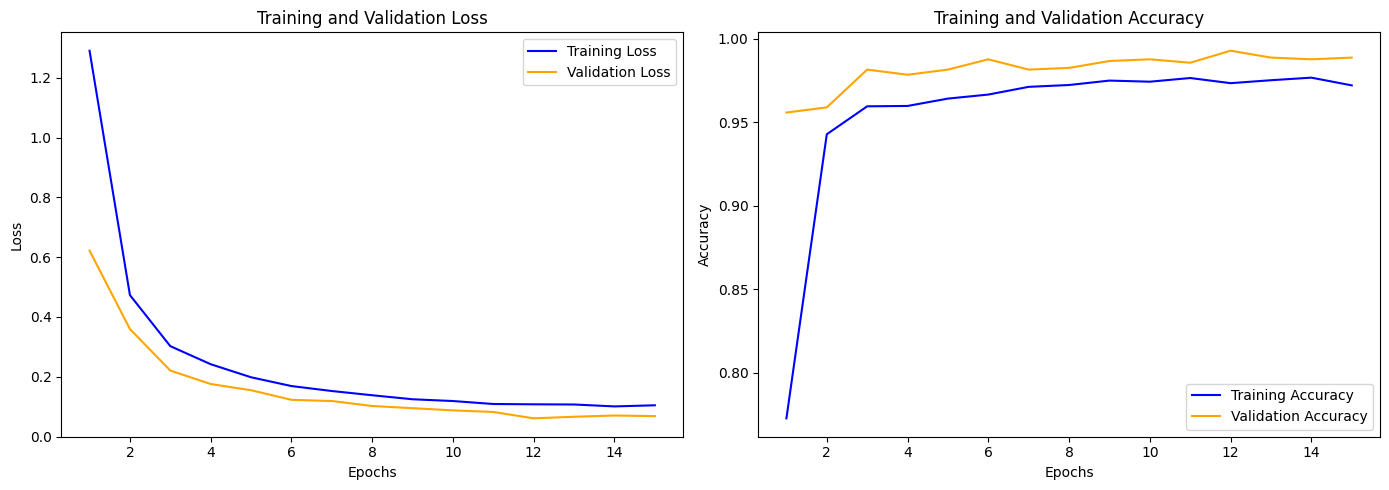

In [7]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Training Loss", color='blue')
plt.plot(epochs_range, history["val_loss"], label="Validation Loss", color='orange')
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Training Accuracy", color='blue')
plt.plot(epochs_range, history["val_acc"], label="Validation Accuracy", color='orange')
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## Step 8: Evaluate Classification Metrics & Generate Confusion Matrix
Calculates Precision, Recall, and the harmonic mean F1-Score for each of the 14 vegetable seed classes using the test set, mapping them in a Confusion Matrix.


=================== TEST SUBSET EVALUATION REPORT ===================
                  precision    recall  f1-score   support

    Bitter melon       1.00      1.00      1.00        55
    Bottle gourd       1.00      0.94      0.97        36
          Carrot       1.00      0.97      0.99        75
     Cauliflower       0.97      1.00      0.99        75
           Chili       1.00      0.99      0.99        75
Coriander leaves       0.97      1.00      0.99        75
        Cucumber       1.00      0.99      0.99        75
   Hyacinth bean       0.97      1.00      0.98        62
 Malabar spinach       1.00      1.00      1.00        75
           Onion       1.00      1.00      1.00        75
          Radish       0.96      1.00      0.98        75
         Spinach       1.00      0.99      0.99        75
          Tomato       0.99      0.96      0.97        75
   Water spinach       1.00      1.00      1.00        75

        accuracy                           0.99       978

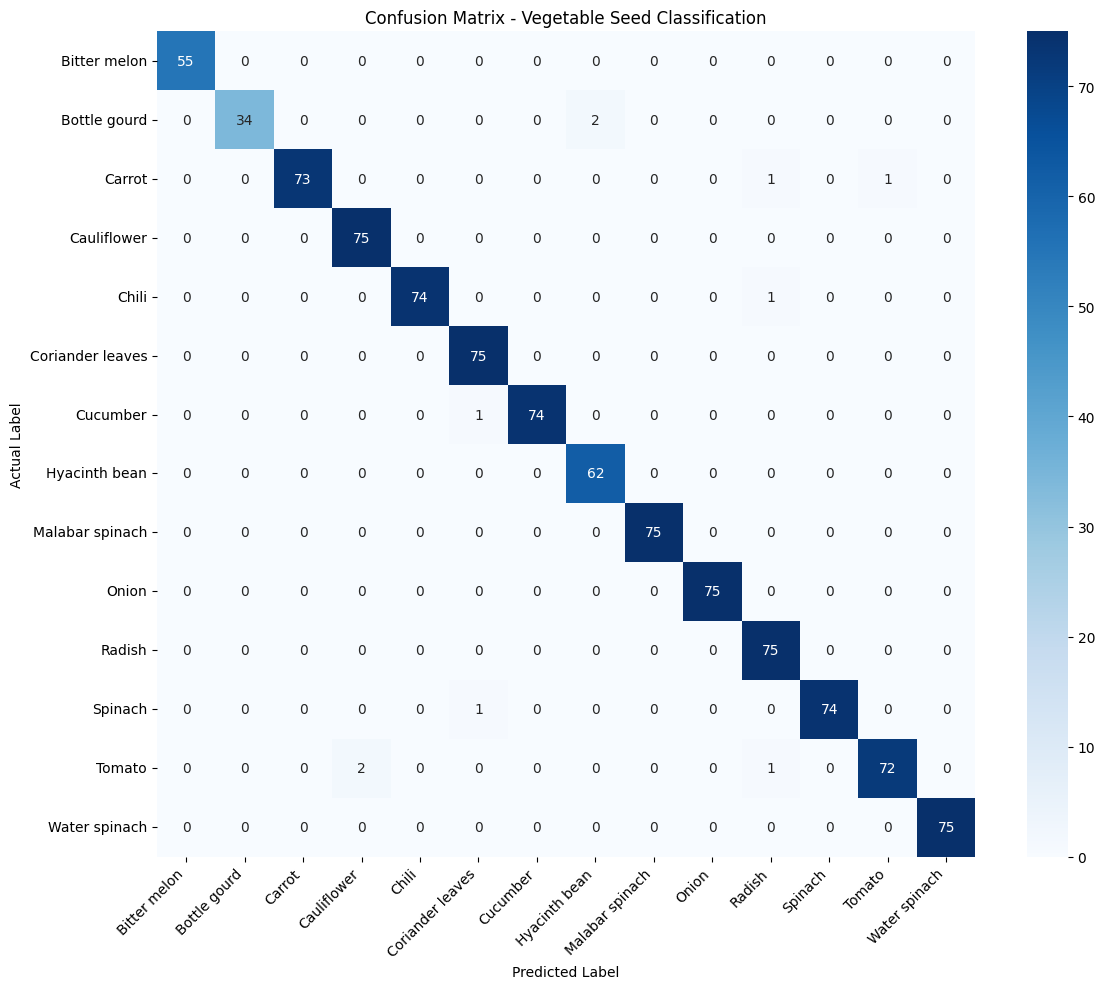

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Load best model weights
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Print Classification Report containing Precision, Recall, and F1-Scores per class
print("\n=================== TEST SUBSET EVALUATION REPORT ===================")
print(classification_report(all_labels, all_preds, target_names=class_names))
print("======================================================================\n")

# Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Vegetable Seed Classification")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Step 9: Export Model to TFLite
Converts the PyTorch weights to ONNX format, then converts ONNX to TensorFlow, and compiles it down to a FP16-quantized TensorFlow Lite model to support offline local device diagnostics.

In [20]:
import os
import shutil
import torch

# 1. Define paths on your mounted Google Drive
drive_weights_dir = "/content/drive/MyDrive/KaggleDatasets/vegetable-seed-dataset/weights/"
os.makedirs(drive_weights_dir, exist_ok=True)

# 2. Save PyTorch weights (Online/Web)
torch.save(model.state_dict(), os.path.join(drive_weights_dir, "best_model.pth"))
print("Saved PyTorch weights to Drive.")

# 3. Save ONNX representation (Online/Web Alternative)
# Moving model and input to CPU to avoid 'FakeTensor' device propagation errors during export
model.cpu()
dummy_input_cpu = torch.randn(1, 3, 224, 224)

torch.onnx.export(
    model,
    dummy_input_cpu,
    os.path.join(drive_weights_dir, "vegetable_seed_classifier.onnx"),
    export_params=True,
    opset_version=18,
    do_constant_folding=True,
    input_names=['input_img'],
    output_names=['output_scores']
)
print("Saved ONNX model to Drive.")

# 4. Save TFLite model (Offline/Edge)
tflite_out_path = "/content/drive/MyDrive/KaggleDatasets/vegetable-seed-dataset/vegetable_seed_mobilenetv2_fp16.tflite"
if os.path.exists(tflite_out_path):
    print("TFLite model is already present in Google Drive.")
else:
    local_tflite = "/content/vegetable_seed_mobilenetv2_fp16.tflite"
    if os.path.exists(local_tflite):
        shutil.copy(local_tflite, tflite_out_path)
        print("Copied TFLite model from local storage to Drive.")

# Restore model to original device
model.to(device)

Saved PyTorch weights to Drive.
[torch.onnx] Obtain model graph for `MobileNetV2([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV2([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
Applied 104 of general pattern rewrite rules.
[torch.onnx] Optimize the ONNX graph... ✅
Saved ONNX model to Drive.


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [23]:
import os
import shutil
from google.colab import files

# Define paths
drive_weights_path = "/content/drive/MyDrive/KaggleDatasets/vegetable-seed-dataset/weights/"
tf_model_dir = "/content/tf_model_temp"
tflite_filename = "vegetable_seed_mobilenetv2_fp16.tflite"
drive_tflite_path = os.path.join(drive_weights_path, tflite_filename)

# Search for the generated tflite file in the output directory
print("Searching for generated TFLite model...")
found_file = None
if os.path.exists(tf_model_dir):
    for root, dirs, files_in_dir in os.walk(tf_model_dir):
        for file in files_in_dir:
            if file.endswith("float16.tflite") or file == tflite_filename:
                found_file = os.path.join(root, file)
                break

if found_file:
    # Copy to Drive
    shutil.copy(found_file, drive_tflite_path)
    # Copy to local for easier download reference
    local_path = f"/content/{tflite_filename}"
    shutil.copy(found_file, local_path)

    print(f"✅ SUCCESS! Model saved to Drive at: {drive_tflite_path}")
    print("Triggering browser download...")
    files.download(local_path)
else:
    print("❌ Error: Could not find the generated .tflite file in the output folder.")

Searching for generated TFLite model...
✅ SUCCESS! Model saved to Drive at: /content/drive/MyDrive/KaggleDatasets/vegetable-seed-dataset/weights/vegetable_seed_mobilenetv2_fp16.tflite
Triggering browser download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
import shutil
from google.colab import files

zip_path = f"{tf_dir}.zip"
shutil.make_archive(tf_dir, 'zip', tf_dir)

print(f"Downloading {zip_path}...")
files.download(zip_path)

# Optional: Clean up the created zip file after download
# os.remove(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>